In [ ]:
# reload the module
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
from contrastive_musicbert.utils.lmd_full_retrieval import get_embeddings_and_refs
from pathlib import Path

def get_clamp_embedding():
    model_name='clamp-1024'
    embedding_dir = './inference/lmd_full_to_lmd_full_0.95__clamp_feature_1024.npy/'
    embedding_file = 'embeddings.pt'
    embedding_refs = 'refs.txt'
    # load the embeddings and refs 
    set_embs, refs = get_embeddings_and_refs(embedding_dir, embedding_file, embedding_refs, sort=True)
         
    return set_embs, refs

def get_ours_embedding():
    embedding_dir = './inference/lmd_full_to_lmd_full/'
    embedding_file = 'embeddings.pt'
    embedding_refs = 'refs.txt'

    set_embs, refs = get_embeddings_and_refs(embedding_dir, embedding_file, embedding_refs, sort=False, mode='encoding')

    # refs = [Path(ref).parent.name + "__" + Path(ref).stem for ref in refs]
    
    return set_embs, refs

set_embs_clamp, refs_clamp = get_clamp_embedding()

set_embs_ours, refs_ours = get_ours_embedding()

print(set_embs_clamp.shape)
print(set_embs_ours.shape)

print(refs_clamp[0])
print(refs_ours[0])

thres_ours = 0.93
thres_clamp = 0.87

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
torch.Size([176420, 768])
['d__d098ebae21e6b020813703e9739a76f7', 'd__dd4175428294561ec1c30803abbc416f', 'd__db85d935d4d49690b5f8a9bee9a4b5d7', 'd__db4e49ac7ab2e0116f24fe318bf07fe0', 'd__d3c5e3b5ccf8019c711b5c1f19355af7']
torch.Size([168662, 512])
['0__00000ec8a66b6bd2ef809b0443eeae41', '0__0000799e8672292fe6f0fff08554ca40', '0__00012722c199ae2a628ebb792ccc617a', '0__000203a04a64ad57329a058f11e235cb', '0__00032fb2047d3cdd0394b89349d858b4']
torch.Size([176420, 768])
torch.Size([168662, 512])
d__d098ebae21e6b020813703e9739a76f7
0__00000ec8a66b6bd2ef809b0443eeae41


In [46]:
inter = len(set(refs_clamp) & set(refs_ours))
union = len(set(refs_clamp) | set(refs_ours))

print(inter, union)

all_refs = set(refs_clamp) | set(refs_ours) 

168407 176675


ours[0].shape

In [7]:
set_embs_ours = set_embs_ours.cuda(1)
set_embs_clamp = set_embs_clamp.cuda(1)

In [8]:
import torch
import torch.nn as nn


def get_high_similarity_indices(set_embs, batch_size=1024, threshold=0.95):
    set_embs = set_embs.half()
    set_embs = nn.functional.normalize(set_embs, dim=1)

    num_samples = set_embs.size(0)
    high_sim_indices = [[] for _ in range(num_samples)]

    for i in range(0, num_samples, batch_size):
        end = min(i + batch_size, num_samples)
        batch = set_embs[i:end]
        
        similarity_batch = torch.mm(batch, set_embs.t())

        for row_idx in range(similarity_batch.size(0)):
            high_sim = (similarity_batch[row_idx] > threshold).nonzero(as_tuple=True)[0]

            if high_sim.numel() > 0:
                sim_values = similarity_batch[row_idx][high_sim]
                sorted_pairs = sorted(
                    zip(high_sim.cpu().tolist(), sim_values.cpu().tolist()),
                    key=lambda x: x[1], 
                    reverse=True  
                )

                high_sim_indices[i + row_idx] = sorted_pairs

        print(f'finished {end}/{num_samples}')

    return high_sim_indices

high_sim_indices_ours = get_high_similarity_indices(set_embs_ours, batch_size=40000, threshold=thres_ours)
high_sim_indices_clamp = get_high_similarity_indices(set_embs_clamp, batch_size=40000, threshold=thres_clamp)
  
# save
from pathlib import Path
import pickle
out_dir = Path('./de-duplication/')
out_dir.mkdir(parents=True, exist_ok=True)
with open(out_dir / f'ours_{thres_ours}_include_self.pkl', 'wb') as f:
    pickle.dump(high_sim_indices_ours, f)
    
with open(out_dir / f'clamp_{thres_clamp}_include_self.pkl', 'wb') as f:
    pickle.dump(high_sim_indices_clamp, f)
from collections import Counter
length_counts_ours = Counter(len(indices) for indices in high_sim_indices_ours)
length_counts_clamp = Counter(len(indices) for indices in high_sim_indices_clamp) 


finished 40000/168662
finished 80000/168662
finished 120000/168662
finished 160000/168662
finished 168662/168662
finished 40000/176420
finished 80000/176420
finished 120000/176420
finished 160000/176420
finished 176420/176420


In [9]:
import pandas as pd
lmd_clean_matched_md5_files = './contrastive_musicbert/metadata/lmd_full_lmd_clean_matched_files_md5.csv'

df = pd.read_csv(lmd_clean_matched_md5_files)
print(df)

                                              Query File  \
0                            Party Animals__Hava Naquila   
1                      The Pasadenas__I'm Doing Fine Now   
2             The Righteous Brothers__Unchained Melody.3   
3      The Righteous Brothers__You've Lost That Lovin...   
4                      The Righteous Brothers__The Blues   
...                                                  ...   
16719                    Andre Hazes__Het laatste rondje   
16720              Andre Hazes__Ik dacht dat het uit was   
16721                            Andre Hazes__Ik meen 't   
16722                               KWS__Please Don't Go   
16723                             McCoys__Hang on Sloopy   

                               Target File  
0      b__bb642baa50109906ab18dcc252d4a171  
1      c__c521b6ed57d8a24132678c1465ab80c4  
2      f__f7e27542112d10dce10a9e152f2bda61  
3      e__e987739202c7a2e3dbfd67ee8a1ed891  
4      7__792d197882d4eea59fb573f193249b5e  
...      

In [10]:
'a__a50289a232a55da778518566109b2a3a' in df['Target File'].values

True

In [11]:
for i in range(2048):
    if len(high_sim_indices_ours[i]) >= 1:
        print(i, high_sim_indices_ours[i])

0 [(0, 1.0), (30148, 0.99169921875), (111024, 0.9892578125), (40336, 0.98828125), (10774, 0.98779296875), (28182, 0.98779296875), (38869, 0.98779296875), (91538, 0.98779296875), (88749, 0.98681640625), (97153, 0.98583984375), (166530, 0.98583984375), (14908, 0.98486328125), (78760, 0.98486328125), (87447, 0.984375), (146664, 0.982421875), (143681, 0.98193359375), (16985, 0.98046875), (37037, 0.97802734375), (18104, 0.97705078125), (9948, 0.97021484375), (92469, 0.95947265625), (54311, 0.95751953125)]
1 [(1, 0.99951171875)]
2 [(2, 1.0)]
3 [(3, 0.99951171875)]
4 [(4, 1.0)]
5 [(5, 1.0)]
6 [(6, 1.0)]
7 [(7, 0.99951171875)]
8 [(8, 1.0), (14176, 0.974609375)]
9 [(9, 1.0), (8518, 0.9990234375)]
10 [(10, 1.0)]
11 [(11, 0.99951171875)]
12 [(12, 1.0)]
13 [(13, 0.99951171875)]
14 [(14, 1.0), (166686, 0.958984375)]
15 [(15, 0.99951171875), (100039, 0.99951171875)]
16 [(16, 0.99951171875)]
17 [(17, 1.0), (160279, 0.97900390625), (150227, 0.9775390625), (72019, 0.97412109375), (57738, 0.97265625), (

In [12]:
def print_length_counts(length_counts):
    print(length_counts)
    # 1 이상인 것 개수
    dup = []
    for key, value in length_counts.items():
        if key >= 2:
            dup.append(value)
            
    print(sum(dup))
    
print_length_counts(length_counts_ours)
# print_length_counts(length_counts_clamp)

Counter({1: 88946, 2: 29720, 3: 14877, 4: 9080, 5: 5594, 6: 4025, 7: 2969, 8: 2194, 9: 1912, 10: 1490, 11: 929, 12: 763, 13: 735, 14: 575, 15: 359, 16: 329, 19: 242, 18: 220, 17: 208, 20: 193, 23: 170, 21: 150, 22: 148, 34: 107, 25: 97, 26: 88, 24: 79, 28: 68, 35: 65, 27: 65, 30: 58, 36: 50, 33: 49, 29: 48, 31: 48, 32: 47, 38: 47, 40: 37, 37: 36, 72: 36, 44: 36, 41: 34, 45: 33, 47: 32, 65: 32, 66: 32, 57: 32, 49: 32, 61: 31, 56: 31, 50: 31, 59: 30, 55: 29, 63: 29, 42: 29, 64: 29, 51: 28, 54: 28, 39: 28, 78: 26, 62: 26, 60: 25, 53: 24, 43: 23, 123: 22, 77: 22, 52: 22, 68: 22, 84: 22, 58: 22, 46: 21, 75: 21, 102: 20, 67: 20, 48: 20, 73: 20, 76: 19, 94: 18, 90: 17, 80: 17, 118: 17, 121: 17, 105: 16, 89: 16, 69: 16, 81: 16, 71: 15, 117: 15, 70: 15, 87: 15, 122: 15, 86: 15, 116: 14, 96: 14, 113: 14, 120: 13, 74: 13, 91: 13, 98: 13, 114: 13, 119: 13, 128: 13, 111: 13, 112: 12, 115: 12, 79: 12, 85: 12, 108: 11, 88: 11, 83: 11, 103: 11, 110: 10, 109: 10, 100: 10, 126: 10, 93: 10, 129: 10, 131:

In [13]:
# 2개 이상인 indices
def get_duplicated_lists(high_sim_indices: list):
    # high sim indices 각 원소의 리스트 길이가 >=2인지 true or false로 반환
    return [len(hs) >= 2 for hs in high_sim_indices]
        

dup_detected_lists_ours = get_duplicated_lists(high_sim_indices_ours)

duplicates_indices_ours = torch.tensor(dup_detected_lists_ours).nonzero().flatten()

dup_detected_lists_clamp = get_duplicated_lists(high_sim_indices_clamp)

duplicates_indices_clamp = torch.tensor(dup_detected_lists_clamp).nonzero().flatten()

In [14]:
duplicates_indices_ours

tensor([     0,      8,      9,  ..., 168656, 168658, 168659])

In [15]:
len(df['Target File'].values)

16724

In [16]:
lmd_clean_hashes = list(df['Target File'].values)
lmd_clean_names = list(df['Query File'].values)

In [41]:
print(lmd_clean_names)

['Party Animals__Hava Naquila', "The Pasadenas__I'm Doing Fine Now", 'The Righteous Brothers__Unchained Melody.3', "The Righteous Brothers__You've Lost That Lovin' Feelin'.4", 'The Righteous Brothers__The Blues', 'The Righteous Brothers__Unchained Melody.1', "The Righteous Brothers__You've Lost That Lovin' Feelin'", 'The Righteous Brothers__Unchained Melody.4', 'The Righteous Brothers__Unchained Melody.6', 'The Righteous Brothers__Unchained Melody.5', 'The Righteous Brothers__Unchained Melody.2', 'The Righteous Brothers__Unchained Melody.7', "The Righteous Brothers__You've Lost That Lovin' Feelin'.3", 'The Righteous Brothers__Unchained Melody', "The Righteous Brothers__You've Lost That Lovin' Feelin'.2", "The Righteous Brothers__You've Lost That Lovin' Feelin'.1", 'Eminem__Guilty Conscience', 'Eminem__Role Model', 'Eminem__Under the Influence', 'Eminem__Kim', 'Eminem__Stan', 'Eminem__The Way I Am', 'Eminem__Bad Meets Evil', 'Eminem__The Real Slim Shady', 'Prince__Interactive', 'Prince_

In [48]:
global_dup_dict = {}

def update_total_dup(duplicates_indices, high_sim_indices, refs, all_refs, global_dup_dict):
    for dup_query_idx in duplicates_indices:
        query_fp = refs[dup_query_idx]
        if query_fp in lmd_clean_hashes:
            index = lmd_clean_hashes.index(query_fp)
            query_fp = lmd_clean_names[index]
            if query_fp not in global_dup_dict.keys():
                global_dup_dict[query_fp] = []    
                
            dup_samples = high_sim_indices[dup_query_idx] # list of (index, sim)
            for dup_detected_idx, dup_sim in dup_samples:
                detected_fp = refs[dup_detected_idx]
                assert detected_fp in all_refs
                
                if detected_fp not in [fp for fp, _ in global_dup_dict[query_fp]]:
                    global_dup_dict[query_fp].append((detected_fp, dup_sim))
                
    return global_dup_dict
            

In [47]:
global_dup_dict = {}
global_dup_dict = update_total_dup(duplicates_indices_clamp, high_sim_indices_clamp, refs_clamp, all_refs, global_dup_dict)
# save as json
import json
with open(out_dir / f'clamp_{thres_clamp}_lmd_clean_lmd_full_include_self.json', 'w') as f:
    json.dump(global_dup_dict, f, indent=4)

d__dd4175428294561ec1c30803abbc416f
d__db85d935d4d49690b5f8a9bee9a4b5d7
d__d4d23ab00b3c45aabb3535db7d5a545c
d__dc33028ef298182a6d0d9e55397c8315
d__d54eb1eb37c673dd8434d80f92dfd6e0
d__d8eedf359b48bc304f43dd0cf78a4e92
d__d240d4322b8961af599b5dfc8408c6b3
d__d85908be7674b7a09968e80efc3d7861
d__da120b4946c689467ee83e36e0d39f9a
d__d1deb6c2b736960ac277694836b02c8e
d__daf17d28b9a18616e173501c4300eaec
d__d590e0aabf4ac317b47b348cd4abba3f
d__d3c15612945dae0130a321fb1405e059
d__dc053b8fe5a64b518c8622b5e90f3ac7
d__d93763d1b2701b78de635d4585f7b123
d__d985ec684f41007831b0792270bb13b5
d__dce9dd28e9f4ccc1116a223cf1bdcc39
d__de342a79857c6a2fc594a7aa71815eb6
d__dc9bfaf17d78abf7498e1cd39efab205
d__d4a0d8fccfa9f31e6a1fdec69b9fe0be
d__d8a2bf0025ab1f370653661a1236a5d1
d__d5d040ea24df507a9116fc8c4df0dbcf
d__d8bc266437a784577720317f6d2cac9f
d__db2389629368f37e0acbd624af4b15a8
d__d3534b791ce32ffc2035c7a070947c0f
d__df863e161eb6e0f27260235e89ab93d0
d__d8db525f4a213034e72d93377f644daf
d__d6ddd5a837d7e4100986fcc05

In [49]:
global_dup_dict = {}
global_dup_dict = update_total_dup(duplicates_indices_ours, high_sim_indices_ours, refs_ours, all_refs, global_dup_dict)
# save as json
import json
with open(out_dir / f'ours_{thres_ours}_lmd_clean_lmd_full_include_self.json', 'w') as f:
    json.dump(global_dup_dict, f, indent=4)
global_dup_dict = update_total_dup(duplicates_indices_clamp, high_sim_indices_clamp, refs_clamp, all_refs, global_dup_dict)
with open(out_dir / f'ours_{thres_ours}_with_clamp_{thres_clamp}_lmd_clean_lmd_full_include_self.json', 'w') as f:
    json.dump(global_dup_dict, f, indent=4)

In [36]:
print(duplicates_indices_ours)

tensor([     0,      8,      9,  ..., 168656, 168658, 168659])


In [51]:
import json

all_version_meta_fp = 'contrastive_musicbert/metadata/lmd_clean_version_counts_augmented.json'

with open(all_version_meta_fp, 'r') as f:
    all_version_meta = json.load(f)
    
dup_dict_agg_song_name = {}

for key, value in global_dup_dict.items():
    if key in all_version_meta.keys(): # duplicate files already in lmd clean
        ori_song_name = min(all_version_meta[key]['versions'], key=len)
    else:
        ori_song_name = key
    if ori_song_name not in dup_dict_agg_song_name.keys():
        dup_dict_agg_song_name[ori_song_name] = []

    for v in value:
        # print(v)
        if v[0] not in [fp for fp, _ in dup_dict_agg_song_name[ori_song_name]]:
            dup_dict_agg_song_name[ori_song_name].append(v)
            
    # self
    if key in all_version_meta.keys():
        for version_fp in all_version_meta[key]['versions']:
            if version_fp in lmd_clean_names:
                index = lmd_clean_names.index(version_fp)
                version_hash_fp = lmd_clean_hashes[index]
                if version_hash_fp not in [fp for fp, _ in dup_dict_agg_song_name[ori_song_name]]:
                    dup_dict_agg_song_name[ori_song_name].append((version_hash_fp, 1.0))
    

In [52]:
dup_dict_agg_song_name

{'Brooks Garth__The Thunder Rolls': [('0__000914ed8544a10c39dffa86c60d9869',
   0.99951171875),
  ('9__97c74f3bb888712e259f12b8430561f0', 0.99951171875),
  ('d__de945c11af978204bba404eeea6da660', 1.0),
  ('e__e61a80a1afac255def8a2417a7a727e7', 1.0),
  ('0__0025d76c7837c183d265e510c81d7da3', 0.99755859375),
  ('3__3f8cddb6b72e44a9af008defd127b4eb', 0.99755859375),
  ('d__d5489021477895ff29bc466149cc2d14', 0.99755859375),
  ('9__94658c71c778d0bcf950fc16202b681e', 0.9833984375),
  ('7__7566168ade9ec6706b7bcfca4ba941c2', 0.974609375),
  ('e__e3362a08e2f9eda33b5a37df5bcf13f9', 0.96826171875)],
 'TURNER TINA__Notbush City Limits': [('0__000e8ebb853db1823528cddee8dde81d',
   1.0009765625),
  ('d__da2b616dc56bc6bef38bd922fbe1d49a', 0.99169921875),
  ('2__2cdb25a9abc795d12679c3f6abc2b212', 1.0)],
 'BOWIE DAVID__Space Oddity': [('0__0018adc7548f9d6e75a937c27a8f36a8', 1.0),
  ('7__77d321f47df3bc1a682a8ccee5d7bd61', 0.99560546875),
  ('3__37d2b4349e3bd529c08eb7ae91eb0dee', 0.94970703125),
  ('0__0

In [53]:
# random select indices that contains duplicates
n = 100
import random
random_select_n_fps = random.sample(list(dup_dict_agg_song_name.keys()), n)

In [54]:
random_select_n_fps

['Pooh__Parsifal (parte II)',
 'Led Zeppelin__Black Country Woman',
 'AL Bano__Felicita',
 'Iron Maiden__Afraid to Shoot Strangers',
 'Sting__Fragile',
 'Take That__Back For Good',
 'The Rolling Stones__Ruby Tuesday',
 'Korn__Got The Life',
 'The Beach Boys__Cool, Cool Water',
 'Oberkrainer__Trompeten-Echo',
 'Keith__98-6',
 'Rembrandts__Just The Way It Is, Baby',
 'Rammstein__Stripped',
 'Richard Sanderson__Reality',
 'Us3__Cantaloop',
 'Fiorello__Lui non ci sara',
 'Stephanie Mills__Never Knew Love Like This Before',
 'Aerosmith__Crazy',
 "Garbage__I'm Only Happy When It Rains",
 'Gary Wright__Love Is Alive',
 'Burton Lane__Too Late Now',
 "Madonna__I'll Remember",
 'Byron Berline__Faded Love',
 'Tony Orlando__Tie a Yellow Ribbon',
 'Major Harris__Sideshow',
 "Maxx__No More (I Can't Stand It)",
 'Huey Lewis & The News__Stuck With You',
 'Annie Lennox__No More "I Love You"s',
 'Barbra Streisand__Evergreen',
 'Jackson Michael__Ben',
 'Masini__Ti vorrei',
 'Seals & Crofts__Diamond Girl'

In [ ]:
from contrastive_musicbert.utils.lmd_full_retrieval import compress_directory
target_dir = out_dir / f'ours_{thres_ours}_with_clamp_{thres_clamp}_lmd_clean_lmd_full'
target_dir.mkdir(parents=True, exist_ok=True)
for query_fp in random_select_n_fps:
    query_hash_name, query_file_name = query_fp.split('__')
    for i, retrieval_sample in enumerate(dup_dict_agg_song_name[query_fp]):
        if i >= 10:
            break # use top 10
        r_fp, sim = retrieval_sample
        retrieved_hash_name, retrieved_file_name = r_fp.split('__')
        _r_fp = Path('../data/lmd_full/') / retrieved_hash_name / (retrieved_file_name + '.mid')
        target_copy_path = Path(target_dir / query_hash_name / query_file_name / retrieved_hash_name / f"{retrieved_file_name}_{sim:.3f}.mid")
        target_copy_path.parent.mkdir(parents=True, exist_ok=True)
        target_copy_path.write_bytes(_r_fp.read_bytes())
        
print('Retrieval done. Compressing the folder') 
compress_directory(target_dir, str(target_dir) + '.tar.gz')

Retrieval done. Compressing the folder


In [56]:
n_files_counter = {key: len(value) for key, value in dup_dict_agg_song_name.items()}

n_files_counter = dict(sorted(n_files_counter.items(), key=lambda x: x[1], reverse=True))


n_clusters = len(n_files_counter)
print(n_clusters, 'song duplicates found')
print(n_files_counter)

6655 song duplicates found
{'Bilk__Fond Memories': 127, 'Led Zeppelin__Stairway To Heaven': 124, 'Carole King__So Far Away': 122, 'Evans Bill__All the Things You Are': 113, 'Fugees__Killing Me Softly': 108, 'Patsy Cline__Crazy': 97, 'Brooks Garth__The Dance': 95, 'Darin Bobby__If I Were a Carpenter': 86, 'Alabama__Then Again': 86, 'Roberta Flack__Killing Me Softly': 85, 'The Beatles__Hey Jude': 82, 'Charlie Rich__Behind Closed Doors': 82, 'Rogers Kenny__She Believes In Me': 78, 'Blood, Sweat & Tears__Sometimes in Winter': 73, 'The Five Satins__In the Still of the Nite': 62, 'Johnny Rivers__Rainy Night in Georgia': 60, 'Tatum Art__The Very Thought of You': 59, 'Scott Joplin__Fig Leaf Rag': 56, 'Queen__We Are the Champions': 54, "Harry Chapin__Cat's In The Cradle": 52, 'Black Rose__Honestly Love You': 51, 'Collins Phil__Another Day in Paradise': 51, 'Andy Williams__MacArthur Park': 50, 'Billy Joel__Piano Man': 49, 'Scott James__Sunburst Rag': 48, 'Scott Joplin__Sugar Cane': 48, 'Bryan Ad

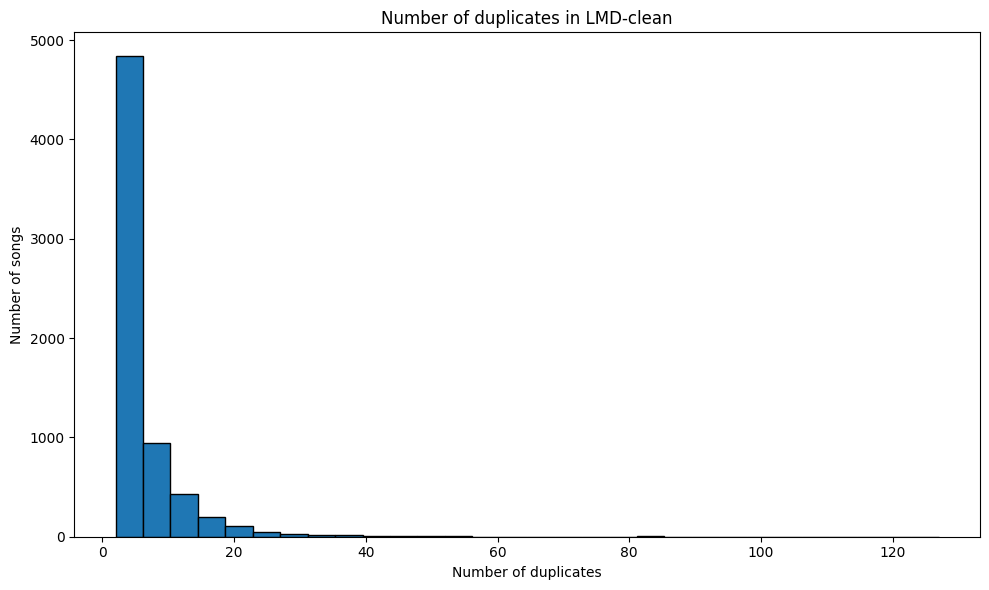

In [57]:
# bar graph
import matplotlib.pyplot as plt
from collections import Counter

count_by_duplicates = Counter(n_files_counter.values())
count_by_duplicates = dict(sorted(count_by_duplicates.items()))

plt.figure(figsize=(10, 6))
plt.hist(n_files_counter.values(), bins=30, edgecolor='black')
plt.xlabel("Number of duplicates")
plt.ylabel("Number of songs")
plt.title("Number of duplicates in LMD-clean")
# plt.xticks(list(count_by_duplicates.keys()))
# plt.xscale('log')
plt.tight_layout()
plt.show()

In [58]:
# total number of duplicated files
total_dups = 0
for key, value in n_files_counter.items():
    total_dups += value
print(total_dups, 'samples are included duplicated files')

40150 samples are included duplicated files


In [59]:
import pickle
with open(out_dir / f'lmd_clusters_ours_{thres_ours}_with_clamp_{thres_clamp}_lmd_clean_lmd_full.pkl', 'wb') as f:
    pickle.dump({
        'dup_dict_agg_song_name': dup_dict_agg_song_name,
        'n_files_in_all_clusters': n_files_counter   
    }, f)

In [ ]:
from contrastive_musicbert.utils.lmd_full_retrieval import compress_directory

# top 50
key_filenames = sorted(n_files_counter, key=n_files_counter.get, reverse=True)[:50]
for fp in key_filenames:
    target_dir = out_dir / f'cluster_ours_{thres_ours}_with_clamp_{thres_clamp}_all_lmd_clean_lmd_full'
    target_dir.mkdir(parents=True, exist_ok=True)
    for i, retrieved_item in enumerate(dup_dict_agg_song_name[fp]):
        r_fp, sim = retrieved_item
        hash_name, file_name = r_fp.split('__')
        _r_fp = Path('../data/lmd_full/') / hash_name / (file_name + '.mid')
        
        target_copy_path = Path(target_dir / f'{n_files_counter[fp]}_{fp}' / f"{hash_name}__{file_name}_{sim}.mid")
        target_copy_path.parent.mkdir(parents=True, exist_ok=True)
        target_copy_path.write_bytes(_r_fp.read_bytes())
            
print('Compressing the folder') 
compress_directory(target_dir, str(target_dir) + '.tar.gz')

Compressing the folder


In [61]:
lmd_clean_names

['Party Animals__Hava Naquila',
 "The Pasadenas__I'm Doing Fine Now",
 'The Righteous Brothers__Unchained Melody.3',
 "The Righteous Brothers__You've Lost That Lovin' Feelin'.4",
 'The Righteous Brothers__The Blues',
 'The Righteous Brothers__Unchained Melody.1',
 "The Righteous Brothers__You've Lost That Lovin' Feelin'",
 'The Righteous Brothers__Unchained Melody.4',
 'The Righteous Brothers__Unchained Melody.6',
 'The Righteous Brothers__Unchained Melody.5',
 'The Righteous Brothers__Unchained Melody.2',
 'The Righteous Brothers__Unchained Melody.7',
 "The Righteous Brothers__You've Lost That Lovin' Feelin'.3",
 'The Righteous Brothers__Unchained Melody',
 "The Righteous Brothers__You've Lost That Lovin' Feelin'.2",
 "The Righteous Brothers__You've Lost That Lovin' Feelin'.1",
 'Eminem__Guilty Conscience',
 'Eminem__Role Model',
 'Eminem__Under the Influence',
 'Eminem__Kim',
 'Eminem__Stan',
 'Eminem__The Way I Am',
 'Eminem__Bad Meets Evil',
 'Eminem__The Real Slim Shady',
 'Prince

In [67]:
import pickle
total_note_counts = pickle.load(open('./de-duplication/lmd_total_notes_per_file.pkl', 'rb'))
whole_removing_files = {}
whole_removing_files_list = []
whole_survived_files_list = []
for i, (key, value) in enumerate(dup_dict_agg_song_name.items()):
    # key to hash_fp
    if key in all_version_meta.keys():
        available_versions = all_version_meta[key]['versions']
        available_versions_idx = [
            lmd_clean_names.index(version) 
            for version in available_versions 
            if version in lmd_clean_names
        ]
        selected_fps = [lmd_clean_hashes[idx] for idx in available_versions_idx]
        selected_hashnames = [fp.split('__')[-1] + '.mid' for fp in selected_fps]        
        note_counts = [total_note_counts[sample_ind] if sample_ind in total_note_counts.keys() else 0 for sample_ind in selected_hashnames]
        max_note_count = max(note_counts)
        max_note_index = note_counts.index(max_note_count)
        selected_fp = selected_fps[max_note_index]
    else:
        index = lmd_clean_names.index(key)
        selected_fp = lmd_clean_hashes[index]

    whole_survived_files_list.append(selected_fp)
    
    other_samples = value.copy()
    other_samples = [other_sample[0] for other_sample in other_samples]

    other_samples.remove(selected_fp)
    assert len(value) == (len(other_samples) + 1)
    whole_removing_files[selected_fp] = other_samples
    whole_removing_files_list.extend(other_samples)
    if i % 1000 == 0:
        print(f'finished {i} / {len(dup_dict_agg_song_name)}')        
    
for key in whole_removing_files.keys():
    # assert key not in whole_removing_files_list
    if key in whole_removing_files_list:
        for k,v in whole_removing_files.items():
            if key in v:
                v.remove(key)
        whole_removing_files_list.remove(key)

remove_ids = []
for r, value in enumerate(whole_removing_files_list):
    # assert value not in whole_survived_files_list
    if value in whole_survived_files_list:
        for k, v in whole_removing_files.items():
            if value in v:
                v.remove(value)
        remove_ids.append(r)
remove_ids = sorted(remove_ids, reverse=True)

for r_id in remove_ids:
    whole_removing_files_list.pop(r_id)
   
 
print(len(whole_removing_files.keys()), len(whole_removing_files_list))
assert len(set(whole_removing_files_list) & set(list(whole_removing_files.keys()))) == 0

target_fp = out_dir / f'ours_{thres_ours}_with_clamp_{thres_clamp}_removing_list_lmd_clean_lmd_full.json'
with open(target_fp, 'w') as f:
    json.dump(whole_removing_files, f, indent=4)

finished 0 / 6655
finished 1000 / 6655
finished 2000 / 6655
finished 3000 / 6655
finished 4000 / 6655
finished 5000 / 6655
finished 6000 / 6655
6654 31488


In [68]:
final_removing_dict = {}
for key, val in whole_removing_files.items():
    index = lmd_clean_hashes.index(key)
    selected_fp = lmd_clean_names[index]
    
    final_removing_dict[selected_fp] = {
        'survived_file': key,
        'remove_file_list': val    
    }

target_fp = out_dir / f'ours_{thres_ours}_with_clamp_{thres_clamp}_removing_list_as_names_lmd_clean_lmd_full.json'
with open(target_fp, 'w') as f:
    json.dump(final_removing_dict, f, indent=4)

In [69]:
print(len(whole_removing_files_list), len(whole_survived_files_list))
print(len(whole_removing_files_list) + len(whole_survived_files_list))

31488 6655
38143
